# Predict body shape

## Prepare Data

The raw data is a NumPy array where each row represents a person. The columns are `height_cm`, `weight_kg`, and `label`. The `label` is 0 for 'not overweight' and 1 for 'overweight'.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Define the features (height_cm, weight_kg)
features_data = np.array([
    [175, 71],
    [160, 63],
    [180, 92],
    [168, 82],
    [155, 50],
    [172, 68],
    [165, 76],
    [190, 96],
    [158, 58],
    [182, 78],
    [170, 88],
    [177, 85],
    [162, 54],
    [185, 74],
    [173, 95],
    [169, 64],
    [181, 89],
    [157, 70],
    [176, 72],
    [164, 61],
])

# Define the labels (0 for 'not overweight', 1 for 'overweight')
labels = np.array([
    0, # [175, 71]
    0, # [160, 63]
    1, # [180, 92]
    1, # [168, 82]
    0, # [155, 50]
    0, # [172, 68]
    1, # [165, 76]
    1, # [190, 96]
    0, # [158, 58]
    0, # [182, 78]
    1, # [170, 88]
    1, # [177, 85]
    0, # [162, 54]
    0, # [185, 74]
    1, # [173, 95]
    0, # [169, 64]
    1, # [181, 89]
    1, # [157, 70]
    0, # [176, 72]
    0, # [164, 61]
])

features = features_data # Now 'features' only contains height and weight

print("== Features ==")
for height, weight in features:
    print(f"Height: {height}, Weight: {weight}")

print("\n== Labels ==")
print(labels)


== Features ==
Height: 175, Weight: 71
Height: 160, Weight: 63
Height: 180, Weight: 92
Height: 168, Weight: 82
Height: 155, Weight: 50
Height: 172, Weight: 68
Height: 165, Weight: 76
Height: 190, Weight: 96
Height: 158, Weight: 58
Height: 182, Weight: 78
Height: 170, Weight: 88
Height: 177, Weight: 85
Height: 162, Weight: 54
Height: 185, Weight: 74
Height: 173, Weight: 95
Height: 169, Weight: 64
Height: 181, Weight: 89
Height: 157, Weight: 70
Height: 176, Weight: 72
Height: 164, Weight: 61

== Labels ==
[0 0 1 1 0 0 1 1 0 0 1 1 0 0 1 0 1 1 0 0]


we can normalize the x, because large difference


In [2]:
#compute max and min
x_min = features.min(axis=0)
x_max = features.max(axis=0)

#normalize
X = (features - x_min) / (x_max - x_min)

print("== Normalized Features ==")
for i in range(len(features)):
  print(f"Data Point {i}: Height={features[i][0]:.4f}, Weight={features[i][1]:.4f}")


== Normalized Features ==
Data Point 0: Height=175.0000, Weight=71.0000
Data Point 1: Height=160.0000, Weight=63.0000
Data Point 2: Height=180.0000, Weight=92.0000
Data Point 3: Height=168.0000, Weight=82.0000
Data Point 4: Height=155.0000, Weight=50.0000
Data Point 5: Height=172.0000, Weight=68.0000
Data Point 6: Height=165.0000, Weight=76.0000
Data Point 7: Height=190.0000, Weight=96.0000
Data Point 8: Height=158.0000, Weight=58.0000
Data Point 9: Height=182.0000, Weight=78.0000
Data Point 10: Height=170.0000, Weight=88.0000
Data Point 11: Height=177.0000, Weight=85.0000
Data Point 12: Height=162.0000, Weight=54.0000
Data Point 13: Height=185.0000, Weight=74.0000
Data Point 14: Height=173.0000, Weight=95.0000
Data Point 15: Height=169.0000, Weight=64.0000
Data Point 16: Height=181.0000, Weight=89.0000
Data Point 17: Height=157.0000, Weight=70.0000
Data Point 18: Height=176.0000, Weight=72.0000
Data Point 19: Height=164.0000, Weight=61.0000


## Data Points with Normalized Features and Labels

In [3]:
print("== Data Points (Normalized Height, Normalized Weight, Label) ==")
for i in range(len(features)):
    print(f"Data Point {i}: Height={features[i][0]:.4f}, Weight={features[i][1]:.4f}, Label={labels[i]}")


== Data Points (Normalized Height, Normalized Weight, Label) ==
Data Point 0: Height=175.0000, Weight=71.0000, Label=0
Data Point 1: Height=160.0000, Weight=63.0000, Label=0
Data Point 2: Height=180.0000, Weight=92.0000, Label=1
Data Point 3: Height=168.0000, Weight=82.0000, Label=1
Data Point 4: Height=155.0000, Weight=50.0000, Label=0
Data Point 5: Height=172.0000, Weight=68.0000, Label=0
Data Point 6: Height=165.0000, Weight=76.0000, Label=1
Data Point 7: Height=190.0000, Weight=96.0000, Label=1
Data Point 8: Height=158.0000, Weight=58.0000, Label=0
Data Point 9: Height=182.0000, Weight=78.0000, Label=0
Data Point 10: Height=170.0000, Weight=88.0000, Label=1
Data Point 11: Height=177.0000, Weight=85.0000, Label=1
Data Point 12: Height=162.0000, Weight=54.0000, Label=0
Data Point 13: Height=185.0000, Weight=74.0000, Label=0
Data Point 14: Height=173.0000, Weight=95.0000, Label=1
Data Point 15: Height=169.0000, Weight=64.0000, Label=0
Data Point 16: Height=181.0000, Weight=89.0000, La

Update weight after every epoch

In [4]:
class Perceptron:
   def __init__(self, learning_rate = 1.0, n_iterations = 100):
    self.lr = learning_rate
    self.n_iterations = n_iterations
    self.weights = None
    self.bias = None
    self.errors_per_epoch = []

   def fit(self, X, y):
    n_samples, n_features = X.shape
    # set all weight and bia to 0
    self.weights = np.zeros(n_features)
    self.bias = 0
    self.errors_per_epoch = []

    # number of errors
    for epoch in range(self.n_iterations):
      errors = 0

# takes z=wTx+b
      for i in range(n_samples):
        x_i = X[i]
        y_true = y[i]

        z = np.dot(x_i, self.weights) + self.bias

        y_pred = 1 if z > 0 else 0
        # error in prediction
        error = y_true - y_pred
        # if predict wrong change the weight and bias
        if error != 0:
          errors += 1

          self.weights += self.lr * error * x_i
          self.bias += self.lr * error
          # print(f"Epoch {epoch + 1}/{self.n_iterations} - Errors: {errors}") # This print causes too much output

      self.errors_per_epoch.append(errors)

      if errors == 0:
        print("Converged!")
        break

    return self

   def predict(self, X):
      z = np.dot(X, self.weights) + self.bias
      return np.where(z > 0, 1, 0)


In [5]:
model = Perceptron(learning_rate = 0.5, n_iterations=100)
model.fit(X, labels)

Converged!


### Model Performance

In [6]:
print("Errors per epoch:", model.errors_per_epoch)
print("Final weights:", model.weights)
print("Final bias:", model.bias)

Errors per epoch: [11, 4, 2, 0]
Final weights: [-0.45714286  1.31521739]
Final bias: -0.5


### Making Predictions

In [7]:
predictions = model.predict(X)

print("Predictions:", predictions)
print("Actual Labels:", labels)

# You can also compare them directly
comparison = np.array([predictions == labels]).T
print("\nComparison (Prediction == Actual):\n", comparison)

Predictions: [0 0 1 1 0 0 1 1 0 0 1 1 0 0 1 0 1 1 0 0]
Actual Labels: [0 0 1 1 0 0 1 1 0 0 1 1 0 0 1 0 1 1 0 0]

Comparison (Prediction == Actual):
 [[ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]]


### Visualize Errors Per Epoch

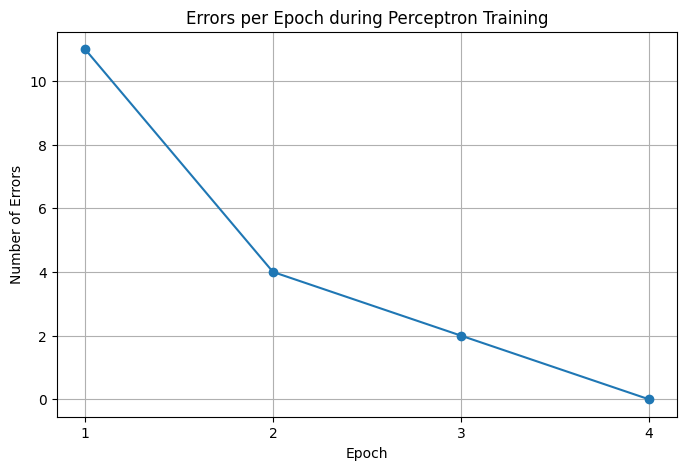

In [8]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(model.errors_per_epoch) + 1), model.errors_per_epoch, marker='o')
plt.title('Errors per Epoch during Perceptron Training')
plt.xlabel('Epoch')
plt.ylabel('Number of Errors')
plt.xticks(range(1, len(model.errors_per_epoch) + 1))
plt.grid(True)
plt.show()

### Predict with New Data

In [9]:
# Generate some new data (height_cm, weight_kg)
new_features_data = np.array([
    [170, 70], # Expected: 0 (not overweight)
    [185, 90], # Expected: 1 (overweight)
    [160, 55], # Expected: 0 (not overweight)
    [175, 85]  # Expected: 1 (overweight)
])

print("== New Raw Data ==")
for height, weight in new_features_data:
    print(f"Height: {height}, Weight: {weight}")


== New Raw Data ==
Height: 170, Weight: 70
Height: 185, Weight: 90
Height: 160, Weight: 55
Height: 175, Weight: 85


In [10]:
# Normalize the new data using the min/max from the training data
# It's crucial to use the same scaling parameters derived from the training set
new_X = (new_features_data - x_min) / (x_max - x_min)

print("== Normalized New Data ==")
for i in range(len(new_X)):
    print(f"Data Point {i}: Normalized Height={new_X[i][0]:.4f}, Normalized Weight={new_X[i][1]:.4f}")


== Normalized New Data ==
Data Point 0: Normalized Height=0.4286, Normalized Weight=0.4348
Data Point 1: Normalized Height=0.8571, Normalized Weight=0.8696
Data Point 2: Normalized Height=0.1429, Normalized Weight=0.1087
Data Point 3: Normalized Height=0.5714, Normalized Weight=0.7609


In [11]:
# Make predictions on the normalized new data
new_predictions = model.predict(new_X)

print("\n== Predictions for New Data ==")
for i in range(len(new_features_data)):
    print(f"Person with Height={new_features_data[i][0]}, Weight={new_features_data[i][1]} is predicted as: {'Overweight' if new_predictions[i] == 1 else 'Not Overweight'}")

print("\nNumerical Predictions:", new_predictions)



== Predictions for New Data ==
Person with Height=170, Weight=70 is predicted as: Not Overweight
Person with Height=185, Weight=90 is predicted as: Overweight
Person with Height=160, Weight=55 is predicted as: Not Overweight
Person with Height=175, Weight=85 is predicted as: Overweight

Numerical Predictions: [0 1 0 1]
